In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

# 本期：把 MLP 换成“层级 CNN”——WaveNet 风格的字符模型

前面几期（Day5–Day9）一直用“整窗 MLP”：把 3 个字符的 embedding 拍平后一次喂进一个全连接隐层。本期换一种更“工程”的吃法：
1. 用 `FlattenConsecutive(2)` 把相邻两个字符**两两合并**——不调 `torch.nn.Conv1d`，但数学上等价于 kernel=2、stride=2 的 1D 卷积；
2. 连做三次合并，时间轴 8 → 4 → 2 → 1，**感受野 1 → 2 → 4 → 8**，最后一层能看到整窗 8 个字符；
3. 因此把 `block_size` 从 3 拉长到 8（长上下文），参数与训练代价却几乎不随窗口增长。

> 注意：这里的 “WaveNet” 沿用 Karpathy 对“逐级收缩、由局部到全局”结构的叫法，与音频合成 WaveNet 不是同一个模型；但理念同源——**低层看小窗口、高层拼大窗口**。

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [5]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


## 数据处理的第一个不同：上下文从 3 拉长到 8

数据构造流程（读 `names.txt` → 建字符表 → `random.seed(42)` 洗牌 → 80/10/10 划分 → 滑窗建 `X/Y`）与前几期**完全一致**，唯一变化在开头一行：

```python
block_size = 8   # 前几期都是 3
```

**为什么这次敢用 8？**
- MLP 时代：窗口多长，第一层就要把多少字符拍平一次喂全连接。窗口 8 意味着首层输入 `8×n_embd`，且字符间“平等相处”，没有局部结构。
- 层级 CNN：**每层只看一对邻居**。窗口加长只是多堆两级合并，Linear 的 fan_in 始终只等于“两个小向量拼起来”（48 或 256），参数几乎不随窗口长度增长。于是 8 字符窗口变得很便宜。

**代价/简化（要接受的两点）**：预测某字符时只看到它左边最近 8 个字符（窗口仍有限）；且合并是固定“二分”，没有滑动重叠——这两点留到文末延伸思考。

In [6]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [7]:
# Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:

  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]

# -----------------------------------------------------------------------------------------------
class FlattenConsecutive:

  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Sequential:

  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]

## 自定义层速览 + 本期主角 `FlattenConsecutive`

`Linear / BatchNorm1d / Tanh / Embedding / Sequential` 都是前几期手写层的“近照复制”（代码注释自己也写了 *Near copy paste of the layers we have developed in Part 3*），只有一处小改动，务必注意：

> **BatchNorm1d 现在要接 3D 输入 (B,T,C)**：新增分支 `x.ndim == 3 → dim = (0,1)`——统计量在 **batch 维和 time 维一起算**（等价于把 B×T 张“图样”当同一批来归一化）。前几期输入是 2D，只归一化 batch 维(dim=0)；本期卷积式结构每层都是 3D 中间量，若仍只按 dim=0 归一会把“同一时间点、不同样本”混为一谈，而且 time 维根本没被归一。

### `FlattenConsecutive` 到底在做什么（本期重点）

```python
def __call__(self, x):
  B, T, C = x.shape
  x = x.view(B, T//self.n, C*self.n)   # 相邻 n 行“通道并排”
  if x.shape[1] == 1:
    x = x.squeeze(1)                   # 只剩 1 行时去掉中间维
  self.out = x
  return self.out
```

**它只做一件事：改变张量形状的解释（reshape），不产生新数据、也没有任何参数。**

- 输入 (B,T,C) → 输出 (B, T/n, C×n)：把**时间上相邻的 n 个位置并成 1 个“更宽的词”**。n=2 时，`t0` 与 `t1` 两行的各 C 个通道拼成一行 2C 宽；
- 为什么用 `view` 而不是 `reshape`：view 是**零拷贝重解释**（要求内存连续；这里的 embedding 结果和 matmul 输出都连续，安全）。`reshape` 在不连续时会悄悄复制；`view` 直接报错——用 view 等于把“不复制”这件事变成可验证的；
- 为什么最后 `squeeze(1)`：设计里 Flatten 后面跟自定义 `Linear`（只做 2D 矩阵乘）。当 T/n=1 时，(B,1,2C) 中长度为 1 的 time 维没有信息，去掉变成 (B,2C)，正好喂给 Linear。

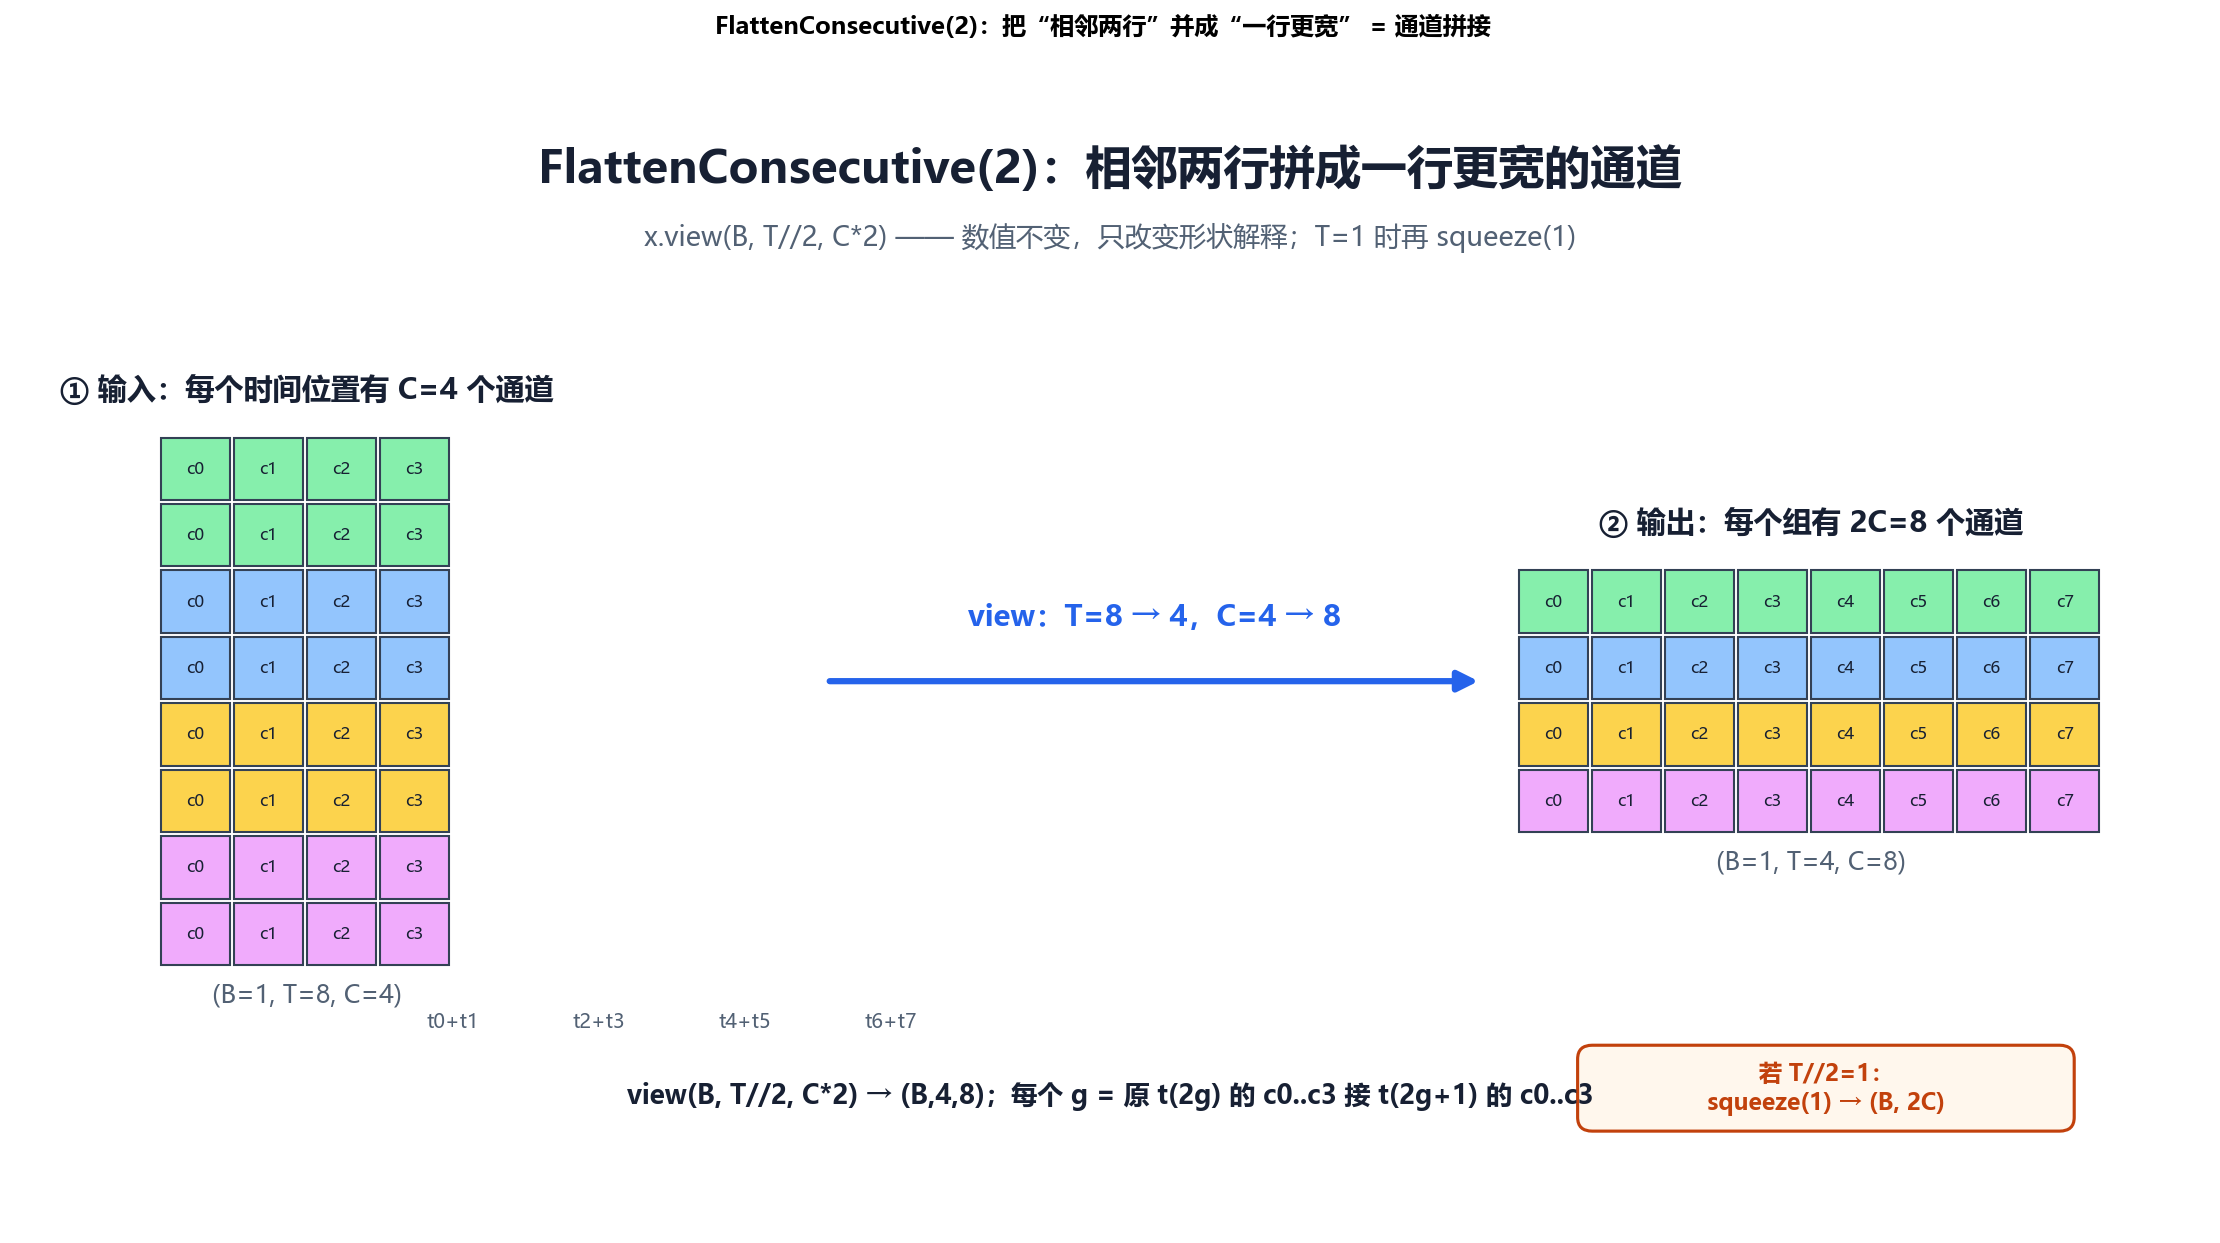

> 图：左为 view 前 (T=8, C=4)，同色两行将被拼成一组；右为 view 后 (T=4, C=8)，每组 = 原 `t_{2g}` 的 c0..c3 接上 `t_{2g+1}` 的 c0..c3——只是内存重新解释，数值一个没变。

### 为什么它“等于”一个卷积

把 (B,T,C) 看成“宽 T、通道 C”的 1D 特征图，则 `FlattenConsecutive(2)` + `Linear(2C→H)` 恰好是 **kernel=2、stride=2、无 padding 的 1D 卷积**：
- `Linear` 对每个时间组用**同一个权重**（权重共享/平移等变），输出 = W·[x_t; x_{t+1}]，与 `Conv1d(H, C, kernel=2)` 的滑窗计算逐项一致（含参数量）；区别只是 Conv1d 显式“滑窗求和”，这里先“并列变宽”再做矩阵乘；
- 三层这样堆叠 = 三层 stride-2 卷积的树，等价于膨胀卷积/小波树那种“局部 → 全局”的层级感受野。

In [8]:
torch.manual_seed(42); # seed rng for reproducibility

In [9]:
# original network
# n_embd = 10 # the dimensionality of the character embedding vectors
# n_hidden = 300 # the number of neurons in the hidden layer of the MLP
# model = Sequential([
#   Embedding(vocab_size, n_embd),
#   FlattenConsecutive(8), Linear(n_embd * 8, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#   Linear(n_hidden, vocab_size),
# ])

# hierarchical network
n_embd = 24 # the dimensionality of the character embedding vectors
n_hidden = 128 # the number of neurons in the hidden layer of the MLP
model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

76579


## 架构：为什么这样堆、每一步形状怎么变

上方注释块里留着 *original network*（整窗 MLP：8 字符一次拍平进 300 隐层）当备选，真正用的是 **hierarchical network**：

```
Embedding(27 → 24)
→ FlattenConsecutive(2) → Linear(48→128)  → BatchNorm1d → Tanh   # (B,8,24)→(B,4,48)→(B,4,128)
→ FlattenConsecutive(2) → Linear(256→128) → BatchNorm1d → Tanh   # (B,4,128)→(B,2,256)→(B,2,128)
→ FlattenConsecutive(2) → Linear(256→128) → BatchNorm1d → Tanh   # (B,2,128)→(B,1,256)→squeeze→(B,256)→(B,128)
→ Linear(128→27)                                                  # (B,128)→(B,27)
```

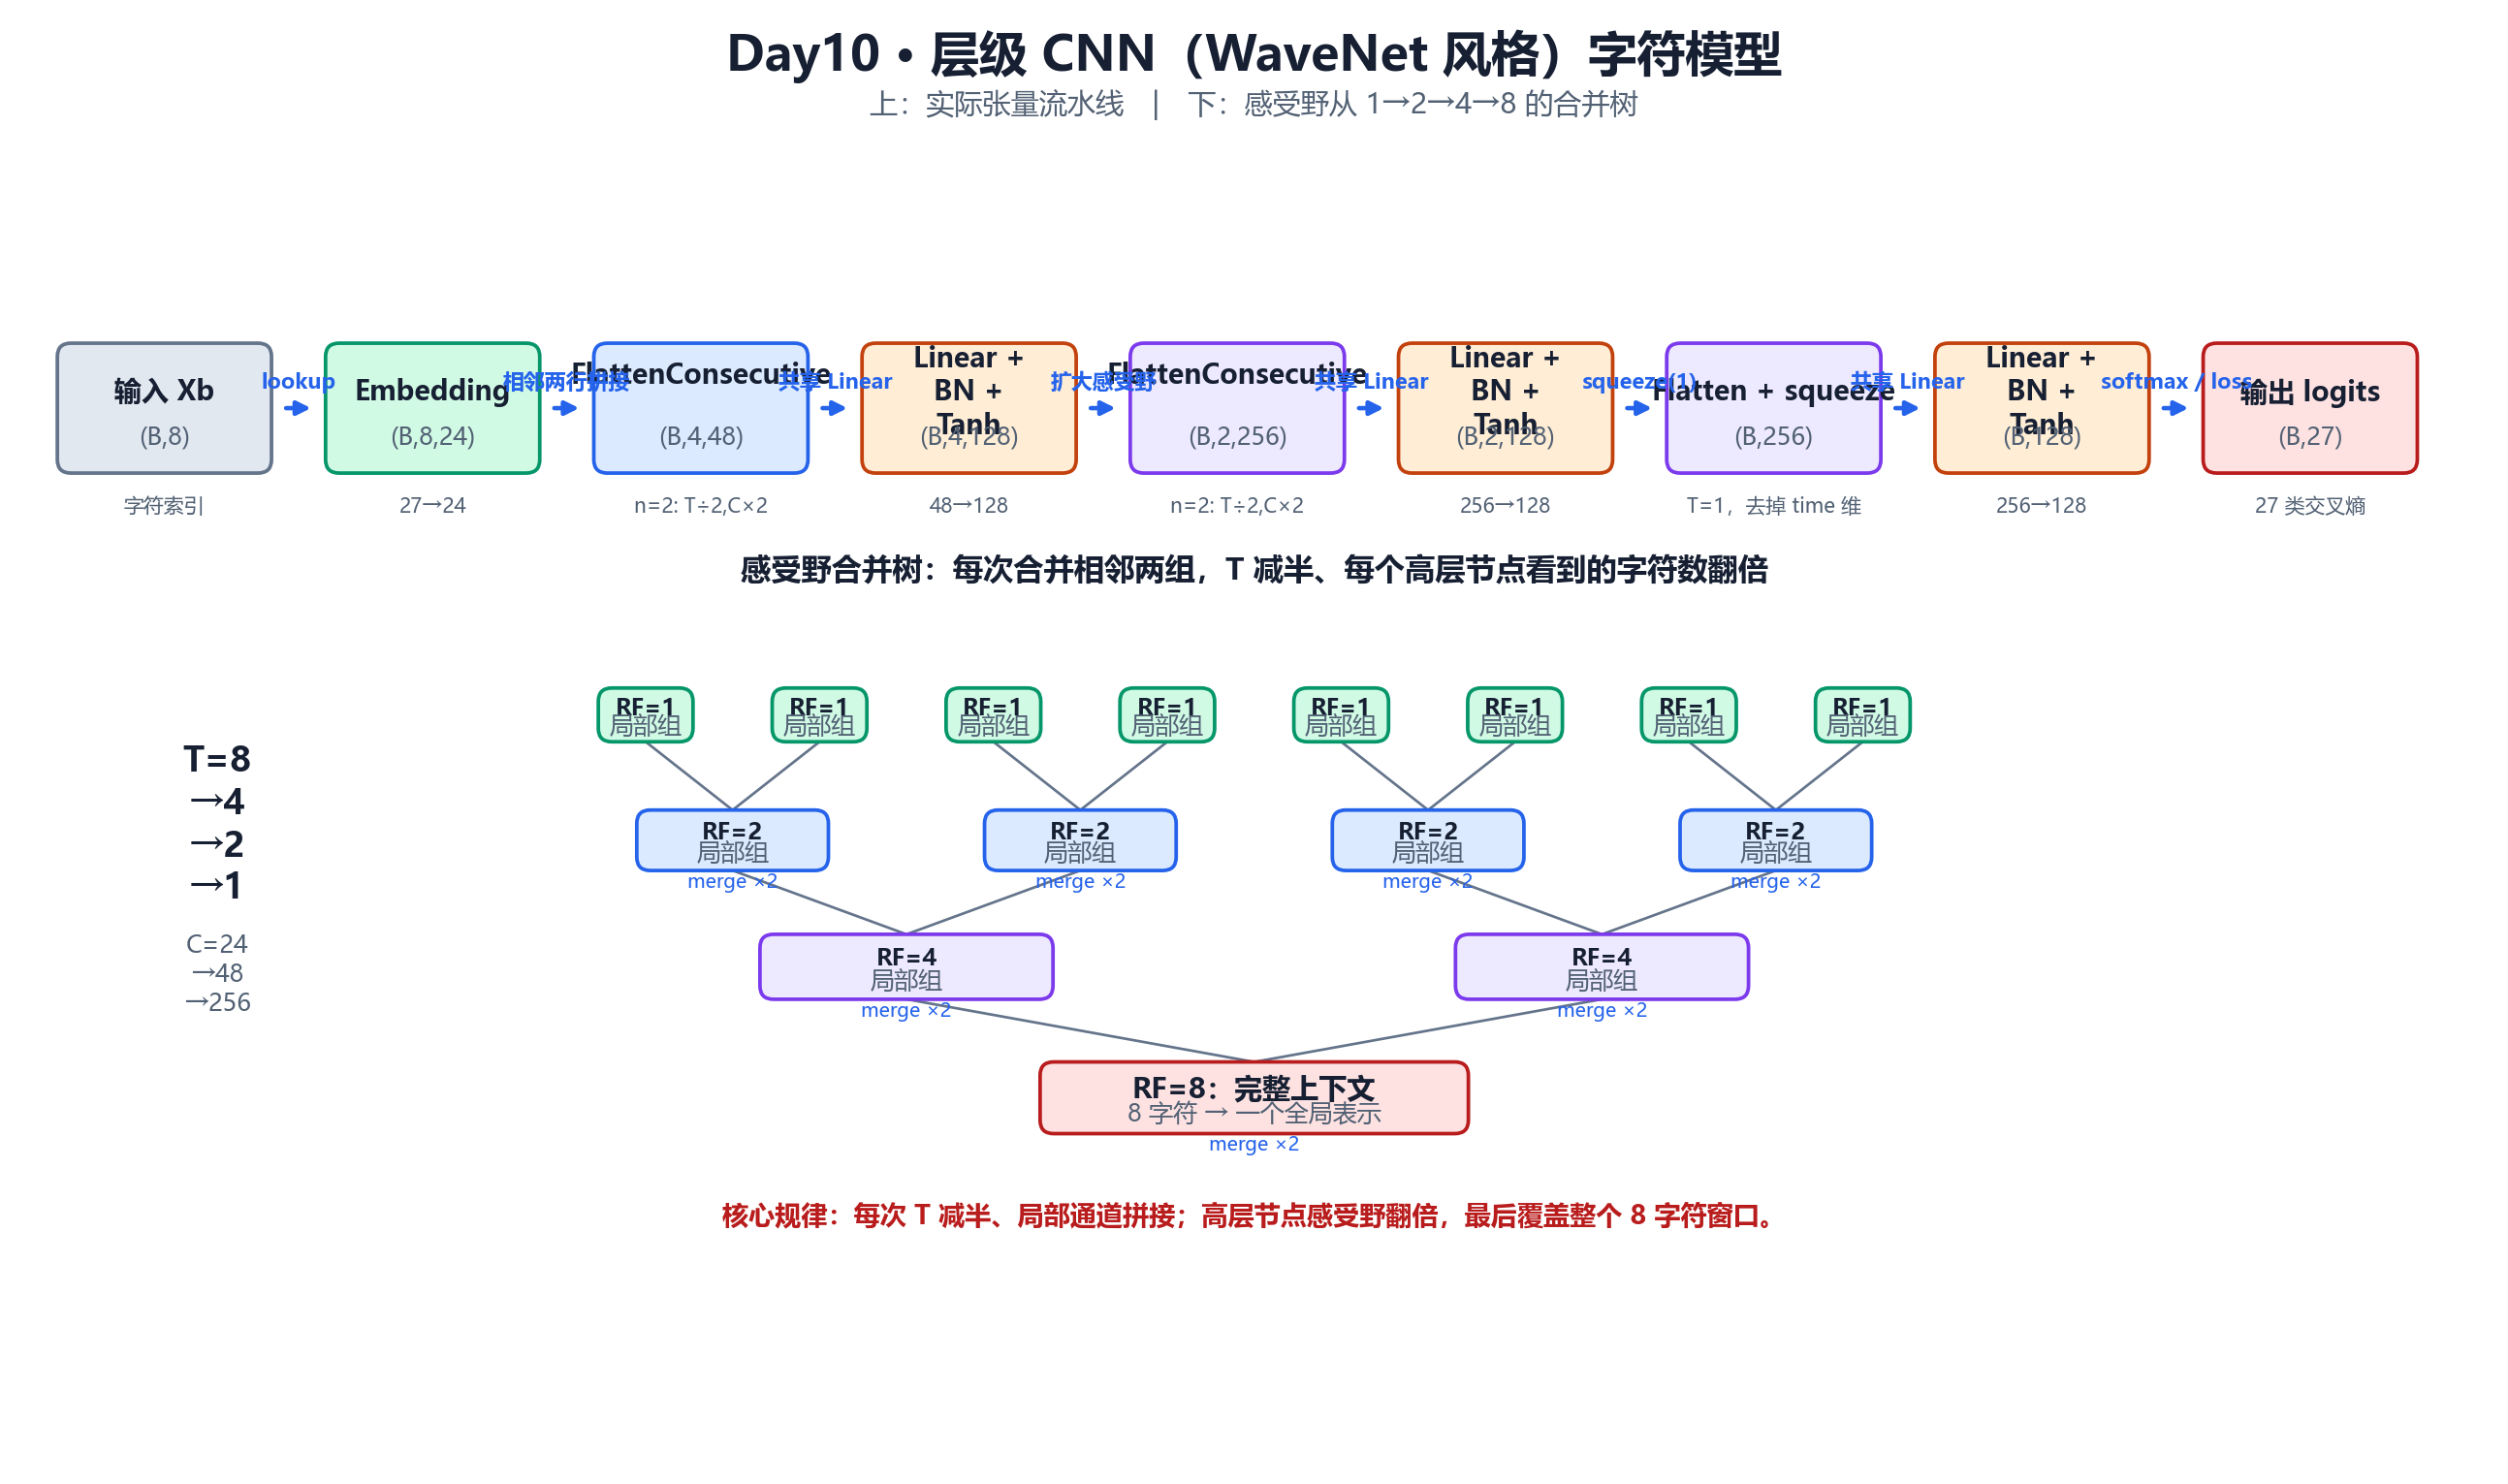

> 图：逐级两两合并的数据流。绿=字符 embedding(24)，蓝=两字符拼接(48)，橙=隐层(128)，紫=四/八字符拼接(256)，红=logits。左侧箭头标出感受野 1→2→4→8：顶部 e0..e7 各只“看到”自己 1 个字符，越往下每组覆盖字符越多，到根覆盖整窗 8 字符。

### 逐层形状与参数量（batch=32 为例）

| 层 | 输入形状 | 输出形状 | 参数 |
|---|---|---|---|
| Embedding(27,24) | (32,8) | (32,8,24) | 648 |
| FlattenConsecutive(2) | (32,8,24) | (32,4,48) | 0 |
| Linear(48,128) bias=False | (32,4,48) | (32,4,128) | 6,144 |
| BatchNorm1d(128) | (32,4,128) | 同左 | 256 |
| FlattenConsecutive(2) | (32,4,128) | (32,2,256) | 0 |
| Linear(256,128) bias=False | (32,2,256) | (32,2,128) | 32,768 |
| BatchNorm1d(128) | (32,2,128) | 同左 | 256 |
| FlattenConsecutive(2) | (32,2,128) | (32,1,256)→squeeze→(32,256) | 0 |
| Linear(256,128) bias=False | (32,256) | (32,128) | 32,768 |
| BatchNorm1d(128) | (32,128) | 同左 | 256 |
| Linear(128,27) | (32,128) | (32,27) | 3,483 |
| **合计** | | | **76,579** |

> 几个“为什么”：
> - 前三个 Linear 都 `bias=False`：紧邻 BatchNorm（自带 β 作偏置），线性层再加 bias 是冗余的——Day8 早已验证过；
> - 第 2、3 个 Linear 的 fan_in=256（=128×2 拼接），不是 128：因为 Flatten 把两行拼成一行更宽的，输入维自然翻倍；
> - 最后一层 `weight *= 0.1`：压低初始 logits，让模型从“一视同仁”的低置信度起步——Day8 的“初始化影响起点”在这里复用。

### 感受野为什么是 1→2→4→8

第一次合并让每个输出组同时握有 2 个字符的信息；第二次把两个“2 字符组”并成“4 字符组”；第三次到“8 字符组”。信息**不是一次看全，而是两两配对、逐层加宽**——这正是它比整窗 MLP 更像 CNN 的地方：低层先捕获局部二元组/四元组模式，高层再组合成整名字的形态。

In [10]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3167
  10000/ 200000: 2.0576
  20000/ 200000: 2.0723
  30000/ 200000: 2.5134
  40000/ 200000: 2.1476
  50000/ 200000: 1.7836
  60000/ 200000: 2.2592
  70000/ 200000: 1.9331
  80000/ 200000: 1.6875
  90000/ 200000: 2.0395
 100000/ 200000: 1.7736
 110000/ 200000: 1.9569
 120000/ 200000: 1.7465
 130000/ 200000: 1.8126
 140000/ 200000: 1.7406
 150000/ 200000: 1.7466
 160000/ 200000: 1.8806
 170000/ 200000: 1.6266
 180000/ 200000: 1.6476
 190000/ 200000: 1.8555


## 训练设置与前几期的三个不同点

训练循环骨架（minibatch → forward → backward → SGD 更新 → 记 lossi）与前几期一致，但有三处参数/细节不同，容易看漏：

1. **学习率衰减点改为 150000 步**：前几期都是 `lr = 0.1 if i < 100000 else 0.01`；本期到 15 万步才从 0.1 降到 0.01。训练拉长时把“大步长热身”阶段延长，是常见做法；
2. **随机性来源不同**：minibatch 用 `torch.randint`，**没有单独的 generator**，只靠前面 cell 的 `torch.manual_seed(42)` 定住全局 RNG。前几期（尤其 Day9 手写反向传播时）用 `g = torch.Generator().manual_seed(...)` 单独管理数据流随机源、并刻意“非标准初始化”以防作弊；本期不需要与 autograd 逐位对账，回归全局 seed 即可；
3. **`lossi` 记 log10 loss、按 1000 步取平均再画**：与 Day8 相同（方便观察 200k 步里的大尺度下降形态）。

其余（200000 步、batch_size=32、SGD 无动量、每 10000 步打印一次）都与前几期相同。

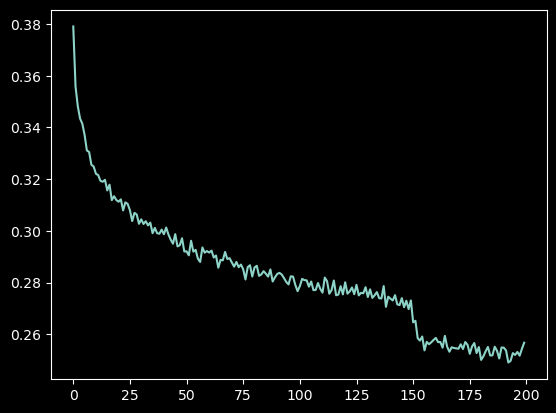

In [11]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

### 这张 loss 曲线怎么读

`lossi` 是每步的 log10 loss，`view(-1,1000).mean(1)` 把每 1000 步切一段取平均——纵轴≈log10(loss)，横轴单位是“千步”：
- 起点约 log10≈0.52（loss≈3.32），接近均匀分布的 `-ln(1/27)≈3.30` 起跑线——说明初始化健康，没有 Day8 那种“初始 27.9 迷之自信”的病；
- 之后快速掉到 ~0.25–0.3（loss≈1.8–2.0）附近长期震荡；
- **曲线很抖**：batch=32 的梯度噪声是常态（Day8 诊断讲过，不是 bug）；这里 `mean(1000)` 后仍抖，说明千步窗口内波动就很大。200k 步对 182k 样本约 32 轮，未完全收敛，看趋势即可。

In [12]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [13]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7690280675888062
val 1.9936524629592896


### 评估结果：train 1.769 / val 1.994

| 模型 | 上下文 | 参数 | train | val |
|---|---|---|---|---|
| 前几期单隐层 MLP（Day5/8 同款） | 3 | ~12k | 2.1256 | 2.1674 |
| 本期层级 CNN | 8 | 76,579 | 1.7690 | 1.9937 |

- val 从 ~2.17 压到 ~1.99：主要功劳是 **8 字符长上下文 + 逐级组合**——模型能参考更长的名字前缀，长名字的一致性好很多；
- 但参数也多了约 6 倍（12k → 76.6k），所以这是“架构+上下文+容量一起变”的整体实验，不是公平对照；
- 两者离最优还有距离（loss 下界 0），说明仍可继续优化。

> 评估代码与前几期一致：先把所有层 `training=False`（手写层没有 `.train()`，只能遍历置位，尤其让 BatchNorm 切到 running 统计），再在 train/val 上算 `F.cross_entropy`。

In [14]:
# sample from the model
for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

arlij.
chetta.
heago.
rocklei.
hendrix.
jamylie.
broxin.
denish.
anslibt.
marianah.
astavia.
annayve.
aniah.
jayce.
nodiel.
remita.
niyelle.
jaylene.
aiyan.
aubreana.


### 采样结果：已经能“拼”出像样的名字

```
arlij.    chetta.    heago.    rocklei.   hendrix.   jamylie.   broxin.
denish.   anslibt.   marianah. astavia.   annayve.   aniah.     jayce.
nodiel.   remita.    niyelle.  jaylene.   aiyan.     aubreana.
```

- 对比 Day5/8 MLP 常见的 jose / mora / yam 这类短名，本期出现 **hendrix / marianah / jaylene / aubreana** 这类更像“完整名字”的长词——8 字符窗口让它在更长距离上维持一致性；
- 偶发 anslibt / broxin 这类拼写瑕疵：窗口仍只有 8 个字符，且数据里本就存在大量稀有拼法；
- 采样方式与之前完全相同：context 滑窗 + `torch.multinomial`（按概率分布采样而非取 argmax），遇到 `.` 停止。

In [15]:
for x,y in zip(Xtr[7:15], Ytr[7:15]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .


In [16]:
# forward a single example:
logits = model(Xtr[[7]])
logits.shape

torch.Size([1, 27])

In [17]:
# forward all of them
logits = torch.zeros(8, 27)
for i in range(8):
  logits[i] = model(Xtr[[7+i]])
logits.shape

torch.Size([8, 27])

## 收工小结：本期到底学了什么

**一句话**：不引入 `torch.nn.Conv1d`，用 `FlattenConsecutive + 共享 Linear` 手拼了一台“逐级两两合并”的层级 CNN，在 8 字符窗口上把 val loss 从 ~2.17 压到 ~1.99。

| 维度 | 前几期 MLP | 本期层级 CNN |
|---|---|---|
| 上下文长度 | 3 | 8 |
| 首层如何看输入 | 整窗拍平、一次全连接 | 两两合并、逐级加宽（1→2→4→8） |
| 局部结构 | 无（字符平等相处） | 有（相邻配对，低层小模式、高层组合） |
| 与卷积的关系 | 无关 | ≈ 三层 kernel=2/stride=2 的 1D 卷积（权重共享） |
| 参数 | ~12k | 76,579 |
| val loss | ~2.17 | ~1.99 |

**延伸思考（给自己留的问题）**
1. 把 `FlattenConsecutive(2)` 改成一次合并 4 个（`n=4`），或混合 2/3/4 步长，效果会如何？（等价于换一种“膨胀卷积树”）
2. 这里 stride=2 **不重叠**；真正的 `Conv1d` 可以 stride=1 滑动重叠窗口。重叠版/膨胀版会更好吗——信息没丢还是过拟合？
3. 采样时每次只前向 1 个样本（batch=1），中间层还能工作吗？能——因为窗口始终是 8（T=8），`squeeze` 只发生在第三次合并后（上面的 cell 已实际验证）。
4. “局部两两 → 全局组合”这条路继续走下去，就是膨胀因果卷积（音频 WaveNet）与 Transformer 的 **token 下采样/混合**；下一步 build-nanogpt 会看到一种完全不同的混合机制——注意力。